# Hybrid Page Extractor — Fence Indicator Study

This notebook reproduces the hybrid ADE + Google OCR walkthrough with a focus on fence indicators. Each step implements an isolated helper so we can verify:

1. Extraction of page sources and chunk segmentation.
2. Identification of fence-related text in non-figure regions.
3. Extraction of indicator tokens and associated descriptions.
4. Matching indicators inside ADE `figure` / `architectural_drawing` chunks.
5. Visual overlays that highlight text and figure hits independently before combining them.



In [ ]:
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import fitz
import json
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import toml
from IPython.display import display
from matplotlib.patches import Rectangle

from hybrid_page_extractor import extract_page_sources, normalize_document_ai_config
from utils_ade import get_ade_fence_boxes
from utils_ade_official import (
    extract_legend_keywords_and_indicators,
    find_indicators_in_figures,
    filter_ocr_by_ade_regions,
)

plt.rcParams["figure.dpi"] = 144
pd.set_option("display.max_rows", 60)
pd.set_option("display.max_columns", None)

print("✅ Environment imports loaded")


✅ Environment imports loaded


In [ ]:
# --- Configuration and Credentials ---
SECRETS_PATH = Path(".streamlit/secrets.toml")
if not SECRETS_PATH.exists():
    raise FileNotFoundError("Expected .streamlit/secrets.toml with API keys.")

secrets = toml.load(SECRETS_PATH)

ADE_API_KEY = secrets.get("LANDINGAI_API_KEY")
if not ADE_API_KEY:
    raise ValueError("Missing LANDINGAI_API_KEY in secrets.toml")

PDF_PATH = Path("subset_gold/selected_pages_no_annotations.pdf")
PAGE_NUMBER = 2  # adjust to inspect a different page

raw_doc_ai_config: Optional[Dict] = None
if "google_cloud" in secrets and "gcp_service_account" in secrets:
    raw_doc_ai_config = {
        "project_number": secrets["google_cloud"].get("project_number"),
        "location": secrets["google_cloud"].get("location"),
        "processor_id": secrets["google_cloud"].get("processor_id"),
        "service_account_info": dict(secrets["gcp_service_account"]),
    }
    doc_ai_config = normalize_document_ai_config(raw_doc_ai_config)
else:
    doc_ai_config = None
    print("⚠️ Google Cloud credentials missing; OCR results will be empty.")

pdf_doc = fitz.open(str(PDF_PATH))
page_index = PAGE_NUMBER - 1
if page_index < 0 or page_index >= len(pdf_doc):
    raise IndexError(f"Page {PAGE_NUMBER} out of bounds for document with {len(pdf_doc)} pages")

pdf_page = pdf_doc[page_index]
page_width = float(pdf_page.rect.width)
page_height = float(pdf_page.rect.height)

print(f"PDF: {PDF_PATH} → {len(pdf_doc)} pages")
print(f"Inspecting page {PAGE_NUMBER} (0-based index {page_index})")
print(f"Page size: {page_width:.1f} × {page_height:.1f} pts")
if doc_ai_config and doc_ai_config.get("client"):
    print("✅ Document AI client initialised")
else:
    print("⚠️ Document AI client not available")


PDF: subset_gold/selected_pages_no_annotations.pdf → 5 pages
Inspecting page 2 (0-based index 1)
Page size: 2592.0 × 1728.0 pts
✅ Document AI client initialised


E0000 00:00:1763413076.437393  768778 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [ ]:
# --- Hybrid extraction for the selected page ---
page_sources = extract_page_sources(
    pdf=PDF_PATH,
    page_number=PAGE_NUMBER,
    ade_api_key=ADE_API_KEY,
    doc_ai_config=doc_ai_config,
)

pdf_words: List[Dict] = page_sources["pdf_words"]
pdf_blocks: List[Dict] = page_sources["pdf_blocks"]
pdf_annotations: List[Dict] = page_sources["pdf_annotations"]
ocr_tokens: List[Dict] = page_sources["ocr_tokens"]
ade_chunks: List[Dict] = page_sources["ade_chunks"]

print("Extraction summary:")
print(f"  PDF words: {len(pdf_words)}")
print(f"  PDF blocks: {len(pdf_blocks)}")
print(f"  PDF annotations: {len(pdf_annotations)}")
print(f"  OCR tokens: {len(ocr_tokens)}")
print(f"  ADE chunks: {len(ade_chunks)}")

with pd.option_context("display.max_colwidth", 120):
    display(pd.DataFrame(ade_chunks)[["id", "type", "x0", "y0", "x1", "y1", "markdown", "text"]].head(6))


Extraction summary:
  PDF words: 1620
  PDF blocks: 334
  PDF annotations: 0
  OCR tokens: 2011
  ADE chunks: 19


,id,type,x0,y0,x1,y1,markdown,text
0,7f0786b1-a306-43ce-887d-0b2d0ccb5e65,figure,136.068051,31.985355,1489.177448,1280.020145,<a id='7f0786b1-a306-43ce-887d-0b2d0ccb5e65'></a>\n\n<::A site plan showing an industrial warehouse building and its...,
1,d2c8a712-5ce4-43ec-973a-70837052037b,table,588.969880,1279.166714,1493.378946,1701.858685,"<a id='d2c8a712-5ce4-43ec-973a-70837052037b'></a>\n\n<table id=""1-1"">\n<tr><td id=""1-2"" colspan=""3"">KEYNOTES</td></t...",
2,5375e5e3-84c1-4e46-ad28-857a35214397,text,1488.795382,33.355419,1939.974936,255.497892,<a id='5375e5e3-84c1-4e46-ad28-857a35214397'></a>\n\n# PROJECT TEAM\n\n## OWNER / DEVELOPER\nRYAN COMPANIES\n3900 E....,
3,ac5bd2d9-1743-4d38-88ba-f646a7c35af7,text,1488.134605,255.449175,1940.470402,471.657280,<a id='ac5bd2d9-1743-4d38-88ba-f646a7c35af7'></a>\n\n## CITY OF PHOENIX NOTES\n\n* DEVELOPMENT AND USE OF THIS SITE ...,
4,1e6f4959-bba3-44bf-b0df-5accecb1845a,text,1487.131931,471.103363,1941.108467,1156.963348,<a id='1e6f4959-bba3-44bf-b0df-5accecb1845a'></a>\n\n## LEGAL DESCRIPTION\n\nA PORTION OF THE WEST HALF OF SECTION 1...,
5,839f3c85-0269-4b21-b147-ec2c694c1495,text,1488.809904,1156.452690,1940.896345,1317.141541,<a id='839f3c85-0269-4b21-b147-ec2c694c1495'></a>\n\n# PROJECT DESCRIPTION\n\nSCOPE OF WORK:\nTHIS SUBMITTAL CONSIST...,


In [ ]:
# --- Page rasterisation utilities ---
RENDER_DPI = 144
page_pix = pdf_page.get_pixmap(dpi=RENDER_DPI)
page_img = np.frombuffer(page_pix.samples, dtype=np.uint8).reshape(page_pix.height, page_pix.width, page_pix.n)
if page_pix.n == 4:
    page_img = page_img[:, :, :3]

scale_x = page_pix.width / page_width
scale_y = page_pix.height / page_height

print(f"Rendered preview at {RENDER_DPI} DPI → image {page_pix.width}×{page_pix.height}")


def show_page(figsize=(10, 14), title: Optional[str] = None):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(page_img)
    ax.set_axis_off()
    if title:
        ax.set_title(title)
    return fig, ax


def add_boxes(
    ax,
    records: List[Dict],
    color: str,
    label_key: Optional[str] = None,
    linewidth: float = 1.4,
    alpha: float = 0.5,
):
    for rec in records:
        x0 = float(rec.get("x0", 0.0)) * scale_x
        y0 = float(rec.get("y0", 0.0)) * scale_y
        x1 = float(rec.get("x1", 0.0)) * scale_x
        y1 = float(rec.get("y1", 0.0)) * scale_y
        width = max(x1 - x0, 1.0)
        height = max(y1 - y0, 1.0)

        rect = Rectangle((x0, y0), width, height, linewidth=linewidth, edgecolor=color, facecolor=(0, 0, 0, 0))
        rect.set_alpha(alpha)
        ax.add_patch(rect)

        if label_key:
            text = rec.get(label_key)
            if text:
                ax.text(
                    x0,
                    max(y0 - 6, 8),
                    str(text)[:42],
                    color="black",
                    fontsize=8,
                    bbox=dict(facecolor=color, alpha=alpha, edgecolor="none", pad=1.5),
                )


Rendered preview at 144 DPI → image 5184×3456


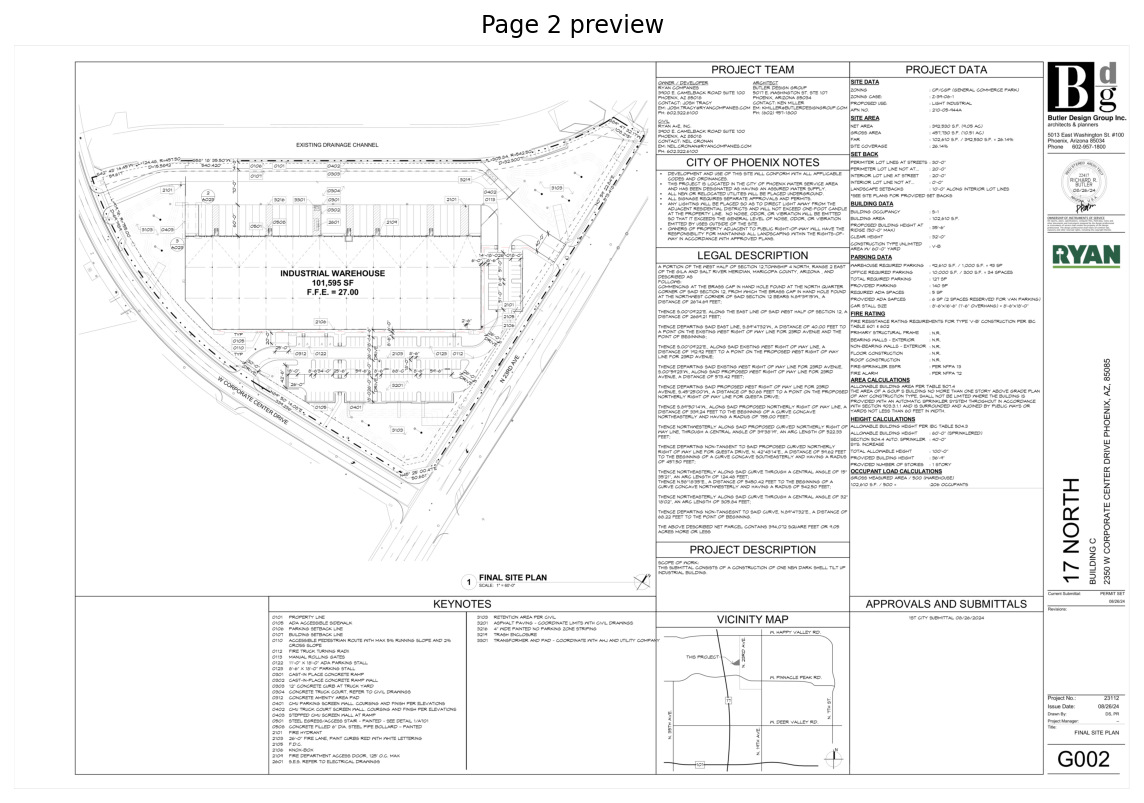

In [ ]:
show_page(title=f"Page {PAGE_NUMBER} preview");


In [ ]:
# --- Helper: Segment ADE chunks by role ---
def segment_chunks(chunks: List[Dict]) -> Tuple[List[Dict], List[Dict], List[Dict]]:
    """Return (legend_like, figure_like, other) partitions.

    Legend-like chunks are everything that is *not* figure/architectural unless the text hints
    that it contains legend content (e.g., "legend" or "keynote").
    """

    legend_like: List[Dict] = []
    figure_like: List[Dict] = []
    other: List[Dict] = []

    for chunk in chunks:
        raw_type = (chunk.get("type") or "").lower()
        text_lower = (chunk.get("markdown") or chunk.get("text") or "").lower()
        is_figure = raw_type in {"figure", "architectural_drawing"}
        has_legend_hint = any(token in text_lower for token in {"legend", "keynote"})

        if not is_figure or has_legend_hint:
            legend_like.append(chunk)
        elif is_figure:
            figure_like.append(chunk)
        else:
            other.append(chunk)

    return legend_like, figure_like, other


legend_like_chunks, figure_chunks, other_chunks = segment_chunks(ade_chunks)

print(
    "Chunk counts → legend-like: {legend}, figure: {fig}, other: {other}".format(
        legend=len(legend_like_chunks), fig=len(figure_chunks), other=len(other_chunks)
    )
)

with pd.option_context("display.max_colwidth", 90):
    display(pd.DataFrame(legend_like_chunks)[["id", "type", "markdown", "text"]].head(8))


Chunk counts → legend-like: 17, figure: 2, other: 0


,id,type,markdown,text
0,d2c8a712-5ce4-43ec-973a-70837052037b,table,"<a id='d2c8a712-5ce4-43ec-973a-70837052037b'></a>\n\n<table id=""1-1"">\n<tr><td id=""1-2...",
1,5375e5e3-84c1-4e46-ad28-857a35214397,text,<a id='5375e5e3-84c1-4e46-ad28-857a35214397'></a>\n\n# PROJECT TEAM\n\n## OWNER / DEVE...,
2,ac5bd2d9-1743-4d38-88ba-f646a7c35af7,text,<a id='ac5bd2d9-1743-4d38-88ba-f646a7c35af7'></a>\n\n## CITY OF PHOENIX NOTES\n\n* DEV...,
3,1e6f4959-bba3-44bf-b0df-5accecb1845a,text,<a id='1e6f4959-bba3-44bf-b0df-5accecb1845a'></a>\n\n## LEGAL DESCRIPTION\n\nA PORTION...,
4,839f3c85-0269-4b21-b147-ec2c694c1495,text,<a id='839f3c85-0269-4b21-b147-ec2c694c1495'></a>\n\n# PROJECT DESCRIPTION\n\nSCOPE OF...,
5,981ee559-43aa-4b17-9a60-28fc7fa7d84a,text,<a id='981ee559-43aa-4b17-9a60-28fc7fa7d84a'></a>\n\n## PROJECT DATA\n\n### SITE DATA\...,
6,d2bb0677-30b5-404c-b8c4-706beadb93d7,logo,<a id='d2bb0677-30b5-404c-b8c4-706beadb93d7'></a>\n\n<::logo: Butler Design Group Inc....,
7,94e7427a-d92c-45c2-bf91-bab7993c80ba,logo,<a id='94e7427a-d92c-45c2-bf91-bab7993c80ba'></a>\n\n<::logo: Richard R. Butler\nREGIS...,


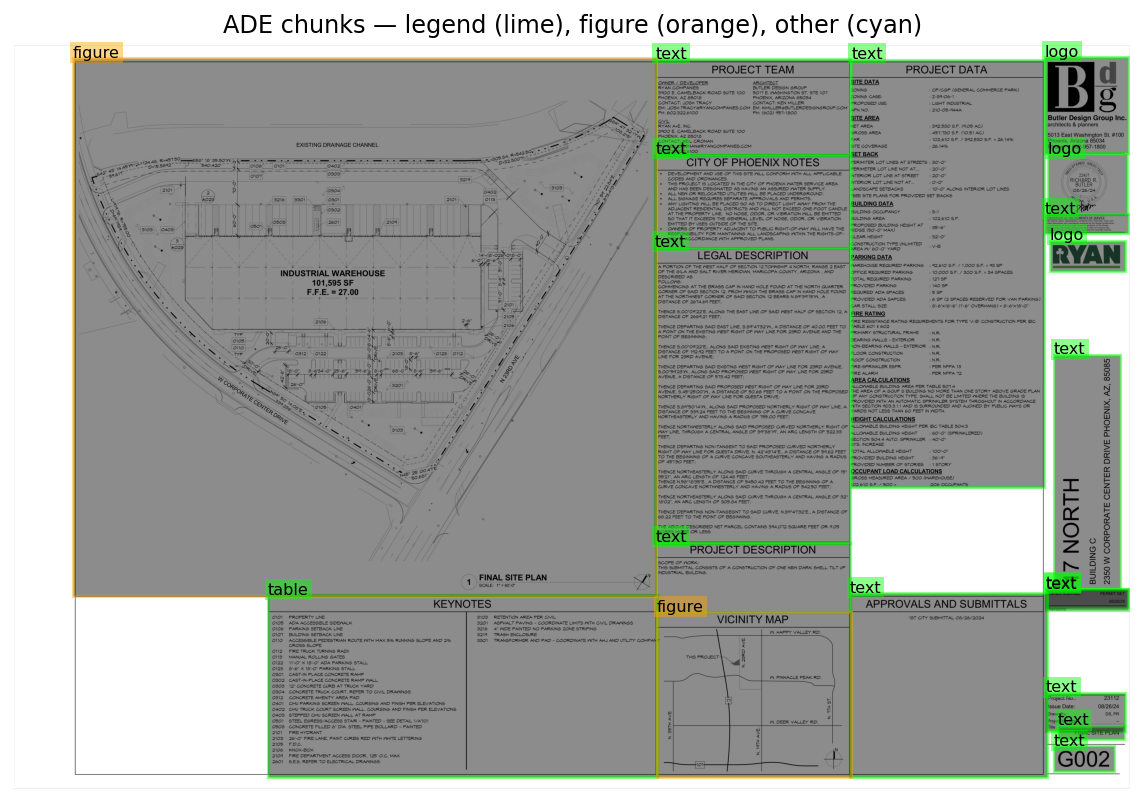

In [ ]:
fig, ax = show_page(title="ADE chunks — legend (lime), figure (orange), other (cyan)")
add_boxes(ax, legend_like_chunks, color="lime", label_key="type", linewidth=1.6, alpha=0.45)
add_boxes(ax, figure_chunks, color="orange", label_key="type", linewidth=1.6, alpha=0.45)
add_boxes(ax, other_chunks, color="cyan", label_key="type", linewidth=1.0, alpha=0.25)
plt.show()


In [ ]:
FENCE_KEYWORDS = [
    "fence",
    "fencing",
    "gate",
    "barrier",
    "guardrail",
    "post",
    "mesh",
    "panel",
    "chain link",
    "masonry",
    "bollard",
    "wall",
    "railing",
    "enclosure",
    "perimeter",
    "screen",
    "security",
]

legend_llm = None
openai_api_key = secrets.get("OPENAI_API_KEY") or secrets.get("openai_api_key")
if openai_api_key:
    try:
        from langchain_openai import ChatOpenAI

        legend_llm = ChatOpenAI(
            model="gpt-4o-mini",
            temperature=0,
            api_key=openai_api_key,
            timeout=180,
            max_retries=2,
        )
        print("✅ Legend LLM initialised (gpt-4o-mini)")
    except Exception as exc:
        print(f"⚠️ Failed to initialise legend LLM: {exc}")
else:
    print("⚠️ OPENAI_API_KEY missing; legend indicator extraction will be skipped.")


✅ Legend LLM initialised (gpt-4o-mini)


In [ ]:
# --- Helper: Fence text search inside non-figure chunks ---
def collect_keyword_mentions(chunks: List[Dict], keywords: List[str]) -> List[Dict]:
    mentions: List[Dict] = []
    for chunk in chunks:
        text = (chunk.get("markdown") or chunk.get("text") or "").lower()
        for kw in keywords:
            if kw.lower() in text:
                mentions.append(
                    {
                        "chunk_id": chunk.get("id"),
                        "keyword": kw,
                        "text": chunk.get("markdown") or chunk.get("text"),
                        "x0": chunk.get("x0"),
                        "y0": chunk.get("y0"),
                        "x1": chunk.get("x1"),
                        "y1": chunk.get("y1"),
                    }
                )
    return mentions


def detect_legend_indicators(
    legend_chunks: List[Dict],
    pdf_words: List[Dict],
    ocr_tokens: List[Dict],
    keywords: List[str],
    llm,
) -> Tuple[List[Dict], List[Dict]]:
    if llm is None:
        print("⚠️ Legend LLM unavailable → skipping indicator extraction.")
        return [], []

    highlights = extract_legend_keywords_and_indicators(
        page_chunks=legend_chunks,
        google_ocr_results=ocr_tokens,
        fence_keywords=keywords,
        page_width=page_width,
        page_height=page_height,
        llm=llm,
        pdf_text_layer_words=pdf_words,
    )

    indicator_records: List[Dict] = []
    for entry in highlights:
        indicator_code = entry.get("indicator_code") or entry.get("text")
        if not indicator_code:
            continue
        indicator_records.append(
            {
                "indicator": str(indicator_code),
                "description": entry.get("description", ""),
                "source": entry.get("source", ""),
                "x0": entry.get("x0"),
                "y0": entry.get("y0"),
                "x1": entry.get("x1"),
                "y1": entry.get("y1"),
            }
        )

    return highlights, indicator_records


keyword_mentions = collect_keyword_mentions(legend_like_chunks, FENCE_KEYWORDS)
legend_highlights, legend_indicator_records = detect_legend_indicators(
    legend_like_chunks,
    pdf_words=pdf_words,
    ocr_tokens=ocr_tokens,
    keywords=FENCE_KEYWORDS,
    llm=legend_llm,
)

legend_keyword_df = pd.DataFrame(keyword_mentions).drop_duplicates(subset=["chunk_id", "keyword"], keep="first")
legend_indicator_df = pd.DataFrame(legend_indicator_records).drop_duplicates(subset=["indicator"], keep="first")

print(f"Keyword mentions (non-figure chunks): {len(legend_keyword_df)}")
print(f"Legend indicator records: {len(legend_indicator_df)}")

if not legend_keyword_df.empty:
    display(legend_keyword_df.head(10))
if not legend_indicator_df.empty:
    display(legend_indicator_df.head(10))


Keyword mentions (non-figure chunks): 7
Legend indicator records: 2


,chunk_id,keyword,text,x0,y0,x1,y1
0,d2c8a712-5ce4-43ec-973a-70837052037b,gate,<a id='d2c8a712-5ce4-43ec-973a-70837052037b'><...,588.969880,1279.166714,1493.378946,1701.858685
1,d2c8a712-5ce4-43ec-973a-70837052037b,bollard,<a id='d2c8a712-5ce4-43ec-973a-70837052037b'><...,588.969880,1279.166714,1493.378946,1701.858685
2,d2c8a712-5ce4-43ec-973a-70837052037b,wall,<a id='d2c8a712-5ce4-43ec-973a-70837052037b'><...,588.969880,1279.166714,1493.378946,1701.858685
3,d2c8a712-5ce4-43ec-973a-70837052037b,enclosure,<a id='d2c8a712-5ce4-43ec-973a-70837052037b'><...,588.969880,1279.166714,1493.378946,1701.858685
4,d2c8a712-5ce4-43ec-973a-70837052037b,screen,<a id='d2c8a712-5ce4-43ec-973a-70837052037b'><...,588.969880,1279.166714,1493.378946,1701.858685
5,981ee559-43aa-4b17-9a60-28fc7fa7d84a,wall,<a id='981ee559-43aa-4b17-9a60-28fc7fa7d84a'><...,1943.694872,34.719767,2391.016989,1026.824387
6,981ee559-43aa-4b17-9a60-28fc7fa7d84a,perimeter,<a id='981ee559-43aa-4b17-9a60-28fc7fa7d84a'><...,1943.694872,34.719767,2391.016989,1026.824387


,indicator,description,source,x0,y0,x1,y1
0,0113,,,597.158359,1416.969257,622.579160,1424.825855
1,0508,,,599.007126,1579.185860,628.125539,1587.504707


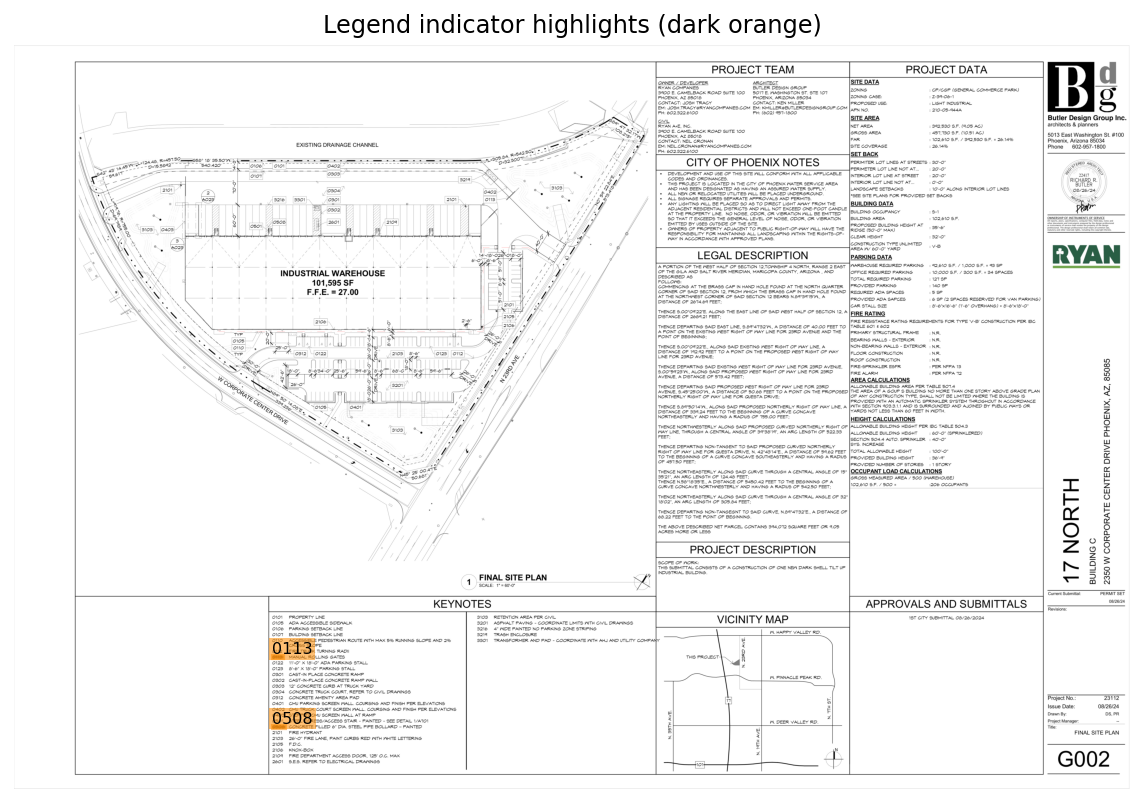

In [ ]:
if legend_highlights:
    fig, ax = show_page(title="Legend indicator highlights (dark orange)")
    add_boxes(ax, legend_highlights, color="darkorange", label_key="indicator_code", linewidth=1.6, alpha=0.55)
    plt.show()
else:
    print("No legend highlights to render.")


In [ ]:
# --- Helper: Indicator search inside figure regions ---
def prepare_indicator_payload(records: List[Dict]) -> List[Dict]:
    payload: List[Dict] = []
    for rec in records:
        indicator = rec.get("indicator")
        if indicator:
            payload.append(
                {
                    "indicator": indicator,
                    "description": rec.get("description", ""),
                }
            )
    return payload


def filter_tokens_to_figures(tokens: List[Dict], figures: List[Dict]) -> List[Dict]:
    if not figures:
        return []
    return filter_ocr_by_ade_regions(tokens, figures)


def locate_indicators_in_figures(
    indicators: List[Dict],
    figure_chunks: List[Dict],
    ocr_tokens: List[Dict],
    keywords: List[str],
    llm,
) -> List[Dict]:
    if llm is None:
        print("⚠️ Legend LLM unavailable → cannot search figure regions.")
        return []
    if not indicators:
        print("⚠️ No indicators supplied → figure search skipped.")
        return []

    figure_tokens = filter_tokens_to_figures(ocr_tokens, figure_chunks)
    print(f"Figure OCR tokens (restricted): {len(figure_tokens)}")

    highlights = find_indicators_in_figures(
        indicators=indicators,
        page_chunks=figure_chunks,
        google_ocr_results=figure_tokens,
        page_width=page_width,
        page_height=page_height,
        llm=llm,
        fence_keywords=keywords,
    )
    return highlights


indicator_payload = prepare_indicator_payload(legend_indicator_records)
figure_indicator_highlights = locate_indicators_in_figures(
    indicators=indicator_payload,
    figure_chunks=figure_chunks,
    ocr_tokens=ocr_tokens,
    keywords=FENCE_KEYWORDS,
    llm=legend_llm,
)

figure_indicator_df = pd.DataFrame(figure_indicator_highlights)
print(f"Figure indicator hits: {len(figure_indicator_df)}")
if not figure_indicator_df.empty:
    display(figure_indicator_df[[col for col in ["text", "indicator_code", "indicator", "x0", "y0", "x1", "y1"] if col in figure_indicator_df.columns]].head(12))


Figure OCR tokens (restricted): 384
Figure indicator hits: 2


,text,x0,y0,x1,y1
0,0508,600.393721,406.234829,630.898729,415.015772
1,0113,1092.171186,354.935534,1117.129815,362.330037


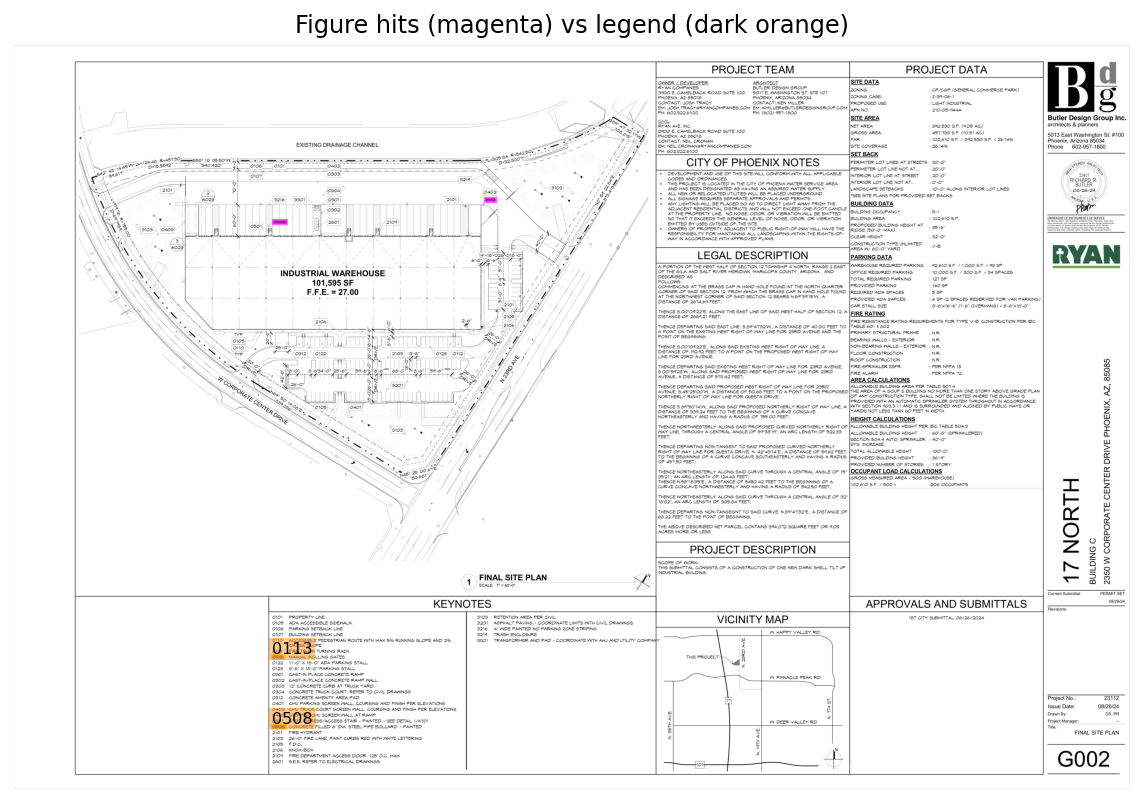

In [ ]:
if figure_indicator_highlights:
    fig, ax = show_page(title="Figure hits (magenta) vs legend (dark orange)")
    add_boxes(ax, legend_highlights, color="darkorange", label_key="indicator_code", linewidth=1.6, alpha=0.45)
    add_boxes(ax, figure_indicator_highlights, color="magenta", label_key="indicator_code", linewidth=1.4, alpha=0.65)
    plt.show()
else:
    print("No figure indicator overlay to render.")


In [ ]:
# --- Validation snapshot of intermediate structures ---
summary_records = [
    {
        "metric": "legend_chunks",
        "value": len(legend_like_chunks),
    },
    {
        "metric": "figure_chunks",
        "value": len(figure_chunks),
    },
    {
        "metric": "legend_keyword_mentions",
        "value": len(legend_keyword_df),
    },
    {
        "metric": "legend_indicators",
        "value": len(legend_indicator_df),
    },
    {
        "metric": "figure_indicator_hits",
        "value": len(figure_indicator_df),
    },
]

summary_df = pd.DataFrame(summary_records)
display(summary_df)


,metric,value
0,legend_chunks,17
1,figure_chunks,2
2,legend_keyword_mentions,7
3,legend_indicators,2
4,figure_indicator_hits,2


In [ ]:
# --- ADE text-layer keyword boxes for comparison ---
ade_keyword_boxes = get_ade_fence_boxes(ade_elements=ade_chunks, fence_keywords=FENCE_KEYWORDS, signals=None)
print(f"ADE keyword-driven highlight boxes: {len(ade_keyword_boxes)}")

if ade_keyword_boxes:
    fig, ax = show_page(title="ADE keyword boxes (green)")
    add_boxes(ax, ade_keyword_boxes, color="lime", label_key="text", linewidth=1.2, alpha=0.35)
    plt.show()
else:
    print("No ADE keyword boxes detected.")


ADE keyword-driven highlight boxes: 0
No ADE keyword boxes detected.


In [ ]:
final_summary = {
    "legend_chunks": len(legend_like_chunks),
    "figure_chunks": len(figure_chunks),
    "legend_keyword_mentions": len(legend_keyword_df),
    "legend_indicators": len(legend_indicator_df),
    "figure_indicator_hits": len(figure_indicator_df),
    "ade_keyword_boxes": len(ade_keyword_boxes),
}
final_summary


{'legend_chunks': 17,
 'figure_chunks': 2,
 'legend_keyword_mentions': 7,
 'legend_indicators': 2,
 'figure_indicator_hits': 2,
 'ade_keyword_boxes': 0}

In [ ]:
pdf_doc.close()


In [17]:
# --- LLM helper: extract paired fence indicators and text elements ---
def llm_extract_fence_elements(
    llm,
    text: str,
    keywords: Optional[List[str]] = None,
    max_items: int = 100,
) -> List[Dict]:
    """Use the configured LLM to extract paired fence indicators and text elements.

    Parameters
    ----------
    llm : BaseLanguageModel
        LangChain-compatible chat model (e.g., ChatOpenAI).
    text : str
        Raw text blob (legend chunk, paragraph, etc.) to analyse.
    keywords : Optional[List[str]]
        Keyword hints to provide additional context to the model.
    max_items : int
        Maximum number of indicator entries to return.

    Returns
    -------
    List[Dict]
        A list of dicts with keys: ``indicator``, ``text_element``, ``indicator_type``, ``description``.
        The function is resilient to malformed LLM outputs and falls back to
        keyword matches if structured parsing fails.
    """
    if not llm:
        raise ValueError("LLM instance is required for llm_extract_fence_elements")
    if not text:
        return []

    hint_keywords = ", ".join(sorted(set((keywords or FENCE_KEYWORDS))))
    analysis_prompt = f"""
You are an assistant reviewing engineering drawing documentation. Extract fence-related
legend entries, callouts or tags and provide paired indicator + text elements. Only return
items that clearly map to fence, gate, barrier, guardrail, rail, wall or similar protective
features.

Text to analyse (between <TEXT> tags):
<TEXT>
{text.strip()[:4000]}
</TEXT>

If no relevant items are present, respond with an empty JSON list ``[]``.
Otherwise, respond with a JSON array where each element has:
- "indicator": the numeric or symbolic tag (e.g., "1", "F-3", "A")
- "text_element": the textual description for that indicator (e.g., "existing fence")
- "indicator_type": legend, keynote, callout, note, etc. (string)
- "description": concise sentence on how the element relates to fencing

Use these keywords as hints: {hint_keywords}
Limit the output to {max_items} entries. If the source text already combines indicator and
text, split them accordingly.
""".strip()

    try:
        raw_response = llm.invoke(analysis_prompt)
        response_text = getattr(raw_response, "content", raw_response)
    except Exception as exc:  # pragma: no cover - interactive guard
        print(f"⚠️ LLM call failed in llm_extract_fence_elements: {exc}")
        response_text = "[]"

    parsed: List[Dict] = []
    if isinstance(response_text, str):
        candidate = response_text.strip()
        # Attempt to locate JSON substring
        json_start = candidate.find("[")
        json_end = candidate.rfind("]") + 1
        if json_start != -1 and json_end > json_start:
            candidate = candidate[json_start:json_end]
        try:
            parsed_json = json.loads(candidate)
            if isinstance(parsed_json, list):
                for item in parsed_json[:max_items]:
                    if not isinstance(item, dict):
                        continue
                    indicator = str(item.get("indicator") or "").strip()
                    text_element = str(item.get("text_element") or "").strip()
                    description = str(item.get("description") or "").strip()
                    if not indicator and not text_element and not description:
                        continue
                    parsed.append(
                        {
                            "indicator": indicator,
                            "text_element": text_element,
                            "indicator_type": str(item.get("indicator_type") or "unknown").strip(),
                            "description": description,
                        }
                    )
        except json.JSONDecodeError:
            pass

    if parsed:
        return parsed

    # Fallback: surface naive keyword matches if JSON parsing failed
    fallback_hits = []
    lowered = text.lower()
    for kw in (keywords or FENCE_KEYWORDS):
        if kw.lower() in lowered:
            fallback_hits.append(
                {
                    "indicator": "",
                    "text_element": kw,
                    "indicator_type": "keyword-hit",
                    "description": "Detected via keyword fallback",
                }
            )
    return fallback_hits[:max_items]



In [ ]:
# --- Helper: map legend-derived indicators into figure regions ---
def extract_figure_indicator_elements_from_llm(
    llm_results_df: pd.DataFrame,
    figure_regions: List[Dict],
    ocr_tokens: List[Dict],
    pdf_words: List[Dict],
    indicator_col: str = "indicator",
    text_col: str = "text_element",
) -> List[Dict]:
    """Locate legend indicators inside figure/architectural ADE chunks using OCR/PDF text.

    Parameters
    ----------
    llm_results_df : pd.DataFrame
        DataFrame produced by `llm_extract_fence_elements`, containing indicator/text pairs.
    figure_regions : List[Dict]
        ADE chunks tagged as `figure` or `architectural_drawing` (used for region boundaries).
    ocr_tokens : List[Dict]
        OCR tokens for the page with bounding boxes.
    pdf_words : List[Dict]
        PDF text-layer words with bounding boxes.
    indicator_col : str
        Column in `llm_results_df` holding the indicator token (default "indicator").
    text_col : str
        Column in `llm_results_df` holding the descriptive text associated with the indicator.

    Returns
    -------
    List[Dict]
        List of matches with region metadata and token-level bounding boxes where indicators or
        text elements were found inside figure regions.
    """

    if llm_results_df is None or llm_results_df.empty:
        return []

    indicator_records = []
    for record in llm_results_df.to_dict("records"):
        indicator_value = str(record.get(indicator_col) or "").strip()
        text_value = str(record.get(text_col) or "").strip()
        if not indicator_value and not text_value:
            continue
        indicator_records.append({
            "indicator": indicator_value,
            "text_element": text_value,
        })

    if not indicator_records:
        return []

    def _normalize_token_text(token: Dict) -> str:
        text_val = str(token.get("text") or token.get("word") or "").strip()
        return text_val

    def _normalize_for_compare(text: str) -> str:
        return re.sub(r"\s+", " ", text).strip().lower()

    def _match_sequence(tokens: List[Dict], target_text: str) -> List[Dict]:
        target_words = [w for w in re.split(r"\s+", target_text.strip()) if w]
        if not target_words:
            return []
        normalized_target = [_normalize_for_compare(w) for w in target_words]

        normalized_tokens = [_normalize_for_compare(_normalize_token_text(tok)) for tok in tokens]

        matches: List[Dict] = []
        t_len = len(normalized_target)
        for start_idx in range(0, max(0, len(normalized_tokens) - t_len + 1)):
            window = normalized_tokens[start_idx : start_idx + t_len]
            if window == normalized_target:
                matches.extend(tokens[start_idx : start_idx + t_len])
        return matches

    def _match_indicator(tokens: List[Dict], indicator_text: str) -> List[Dict]:
        indicator_norm = _normalize_for_compare(indicator_text)
        if not indicator_norm:
            return []
        pattern = re.compile(rf"\\b{re.escape(indicator_norm)}\\b")
        matches: List[Dict] = []
        for tok in tokens:
            token_text_norm = _normalize_for_compare(_normalize_token_text(tok))
            if not token_text_norm:
                continue
            if pattern.search(token_text_norm):
                matches.append(tok)
        return matches

    results: List[Dict] = []

    for region in figure_regions:
        region_tokens_ocr = filter_ocr_by_ade_regions(ocr_tokens, [region])
        region_tokens_pdf = filter_ocr_by_ade_regions(pdf_words, [region])
        combined_tokens = region_tokens_ocr + region_tokens_pdf
        if not combined_tokens:
            continue

        for entry in indicator_records:
            indicator_text = entry.get("indicator")
            text_element = entry.get("text_element")

            indicator_matches = _match_indicator(region_tokens_ocr, indicator_text) if indicator_text else []
            if indicator_text and not indicator_matches:
                indicator_matches = _match_indicator(region_tokens_pdf, indicator_text)

            text_matches: List[Dict] = []
            if text_element:
                text_matches = _match_sequence(combined_tokens, text_element)

            if not indicator_matches and not text_matches:
                continue

            def _dedupe_tokens(tokens: List[Dict]) -> List[Dict]:
                seen = set()
                unique_tokens = []
                for tok in tokens:
                    key = (
                        round(float(tok.get("x0", 0.0)), 2),
                        round(float(tok.get("y0", 0.0)), 2),
                        round(float(tok.get("x1", 0.0)), 2),
                        round(float(tok.get("y1", 0.0)), 2),
                        _normalize_token_text(tok),
                    )
                    if key in seen:
                        continue
                    seen.add(key)
                    unique_tokens.append(tok)
                return unique_tokens

            indicator_matches = _dedupe_tokens(indicator_matches)
            text_matches = _dedupe_tokens(text_matches)

            results.append(
                {
                    "chunk_id": region.get("id"),
                    "chunk_type": region.get("type"),
                    "indicator": indicator_text,
                    "text_element": text_element,
                    "indicator_match_count": len(indicator_matches),
                    "text_match_count": len(text_matches),
                    "indicator_matches": indicator_matches,
                    "text_matches": text_matches,
                    "chunk_bbox": {
                        "x0": region.get("x0"),
                        "y0": region.get("y0"),
                        "x1": region.get("x1"),
                        "y1": region.get("y1"),
                    },
                }
            )

    return results



### LLM extraction check on legend-like chunks
We now probe the `llm_extract_fence_elements` helper by feeding non-figure chunks and reviewing the structured output.


In [ ]:
# Collect OCR and PDF text confined to non-figure ADE chunks
non_figure_regions: List[Dict] = []
region_text_payloads: List[Dict] = []

for chunk in legend_like_chunks:
    chunk_type = (chunk.get("type") or "").lower()
    if chunk_type in {"figure", "architectural_drawing", "logo"}:
        continue

    non_figure_regions.append(chunk)

    # Filter OCR tokens and PDF text words within the chunk bounds
    ocr_in_chunk = filter_ocr_by_ade_regions(ocr_tokens, [chunk])
    pdf_words_in_chunk = filter_ocr_by_ade_regions(pdf_words, [chunk])

    if not ocr_in_chunk and not pdf_words_in_chunk:
        continue

    combined_segments: List[str] = []
    for token in ocr_in_chunk:
        text_val = token.get("text")
        if text_val:
            combined_segments.append(str(text_val))
    for word in pdf_words_in_chunk:
        text_val = word.get("text") or word.get("word")
        if text_val:
            combined_segments.append(str(text_val))

    combined_text = " ".join(seg.strip() for seg in combined_segments if seg and seg.strip())

    region_text_payloads.append(
        {
            "region": chunk,
            "ocr_tokens": ocr_in_chunk,
            "pdf_words": pdf_words_in_chunk,
            "combined_text": combined_text,
        }
    )

print(f"Legend-like non-figure regions: {len(non_figure_regions)}")
print(f"Regions with text payloads: {len(region_text_payloads)}")


Legend-like non-figure regions: 14
Regions with text payloads: 14


In [ ]:
import sys
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re


In [23]:
# Use the LLM-based extraction on combined OCR + PDF text per region
llm_results_per_region: List[Dict] = []
if legend_llm is None:
    print("⚠️ Legend LLM unavailable → skipping direct LLM extraction test.")
else:
    for idx, payload in enumerate(region_text_payloads, start=1):
        combined_text = payload.get("combined_text", "")
        if not combined_text.strip():
            continue
        hits = llm_extract_fence_elements(
            llm=legend_llm,
            text=combined_text,
            keywords=FENCE_KEYWORDS,
            max_items=12,
        )
        if hits:
            region = payload["region"]
            for hit in hits:
                hit["source_chunk_id"] = region.get("id")
                hit["source_chunk_type"] = region.get("type")
                hit["source_chunk_index"] = idx
                hit["ocr_token_count"] = len(payload.get("ocr_tokens", []))
                hit["pdf_word_count"] = len(payload.get("pdf_words", []))
            llm_results_per_region.extend(hits)

print(f"LLM hits across combined-text regions: {len(llm_results_per_region)}")
if llm_results_per_region:
    llm_results_df = pd.DataFrame(llm_results_per_region)
    display(llm_results_df.head(20))


LLM hits across combined-text regions: 8


,indicator,text_element,indicator_type,description,source_chunk_id,source_chunk_type,source_chunk_index,ocr_token_count,pdf_word_count
0,0113,MANUAL ROLLING GATES,keynote,This entry refers to a type of gate that can b...,d2c8a712-5ce4-43ec-973a-70837052037b,table,1,239,196
1,0401,CMU PARKING SCREEN WALL. COURSING AND FINISH P...,keynote,This entry describes a masonry wall that serve...,d2c8a712-5ce4-43ec-973a-70837052037b,table,1,239,196
2,0402,CMU TRUCK COURT SCREEN WALL. COURSING AND FINI...,keynote,This entry describes a masonry wall that acts ...,d2c8a712-5ce4-43ec-973a-70837052037b,table,1,239,196
3,0403,STEPPED CMU SCREEN WALL AT RAMP,keynote,This entry refers to a stepped masonry wall th...,d2c8a712-5ce4-43ec-973a-70837052037b,table,1,239,196
4,0508,CONCRETE FILLED 6” DIA. STEEL PIPE BOLLARD – P...,keynote,This entry describes a bollard that acts as a ...,d2c8a712-5ce4-43ec-973a-70837052037b,table,1,239,196
5,3219,TRASH ENCLOSURE,keynote,This entry refers to a structure that encloses...,d2c8a712-5ce4-43ec-973a-70837052037b,table,1,239,196
6,,wall,keyword-hit,Detected via keyword fallback,981ee559-43aa-4b17-9a60-28fc7fa7d84a,text,6,486,367
7,,perimeter,keyword-hit,Detected via keyword fallback,981ee559-43aa-4b17-9a60-28fc7fa7d84a,text,6,486,367


In [24]:
# Apply the figure extraction helper using LLM outputs
if 'llm_results_df' not in globals() or llm_results_df is None or llm_results_df.empty:
    print("⚠️ No LLM legend results available; run previous cells first.")
    figure_indicator_elements = []
else:
    figure_indicator_elements = extract_figure_indicator_elements_from_llm(
        llm_results_df=llm_results_df,
        figure_regions=figure_chunks,
        ocr_tokens=ocr_tokens,
        pdf_words=pdf_words,
    )
    print(f"Figure indicator element hits: {len(figure_indicator_elements)}")

if figure_indicator_elements:
    figure_indicator_summary = []
    for item in figure_indicator_elements:
        figure_indicator_summary.append(
            {
                "chunk_id": item.get("chunk_id"),
                "chunk_type": item.get("chunk_type"),
                "indicator": item.get("indicator"),
                "text_element": item.get("text_element"),
                "indicator_match_count": item.get("indicator_match_count"),
                "text_match_count": item.get("text_match_count"),
            }
        )
    figure_indicator_df = pd.DataFrame(figure_indicator_summary)
    display(figure_indicator_df.head(20))



Figure indicator element hits: 0
